In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as sps
import seaborn as sns

In [ ]:
Задание 1.

In [ ]:
 rng = np.random.default_rng(seed=1234)
 np.random.normal(size=10)

array([-0.47542706,  0.17839461, -0.39542956, -0.14053098, -0.27562495,
        0.85548509, -0.36407062, -0.29821165,  0.948572  ,  0.41835756])

Задание 2. Вариант 4.

In [ ]:
df = pd.read_csv('/mobile_phones.csv')
print(len(df))
print(df.head(10))

2000
   battery_power  blue  clock_speed  dual_sim  fc  four_g  int_memory  m_dep  \
0            842     0          2.2         0   1       0           7    0.6   
1           1021     1          0.5         1   0       1          53    0.7   
2            563     1          0.5         1   2       1          41    0.9   
3            615     1          2.5         0   0       0          10    0.8   
4           1821     1          1.2         0  13       1          44    0.6   
5           1859     0          0.5         1   3       0          22    0.7   
6           1821     0          1.7         0   4       1          10    0.8   
7           1954     0          0.5         1   0       0          24    0.8   
8           1445     1          0.5         0   0       0          53    0.7   
9            509     1          0.6         1   2       1           9    0.1   

   mobile_wt  n_cores  ...  px_height  px_width   ram  sc_h  sc_w  talk_time  \
0        188        2  ...        

In [ ]:
# Можно вставить 2 сим-карты
def df_sum(column):
  return df[column].sum()

print(df_sum('dual_sim'))

1019


In [ ]:
# Поддерживают 3-G
print(df_sum('three_g'))

1523


In [ ]:
# Наибольшее число ядер у процессора
def df_max(column):
  return df[column].max()

print(df_max('n_cores'))

8


In [ ]:
# Выборочное среднее
def df_mean(column):
  return sum(df[column])//len(df)

print(df_mean('battery_power'))

1238


In [ ]:
# Выборочная дисперсия
def df_variance(column):
  e = 0
  mean = df_mean(column)
  for i in range(len(df)):
    e += (df[column][i] - mean)**2
  return e/len(df)

print(df_variance('battery_power'))

192992.0845


In [ ]:
# Выборочная медиана
def df_median(column):
  s_df = df.sort_values(column)
  median = len(s_df)//2
  if (len(df) % 2):
      return s_df[column][median]
  else:
      return s_df[column][median] + s_df[column][median + 1] / 2.0

print(df_median('battery_power'))

1356.0


In [ ]:
# Выборочная квантиль порядка 2/5
def df_quantile(column, x):
  return df[column].quantile(x)

print(df_quantile('battery_power', 0.4))

1076.0


<Axes: xlabel='battery_power', ylabel='Density'>

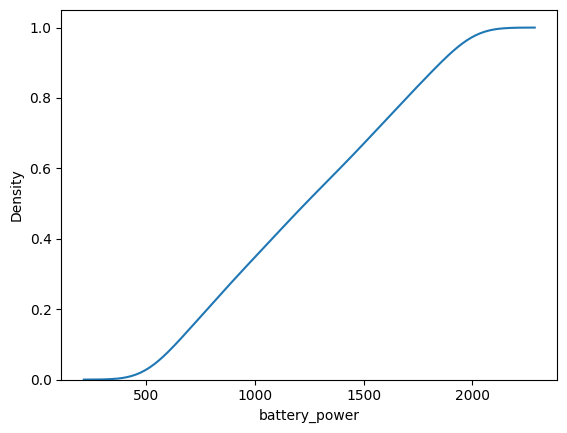

In [ ]:
# График эмпирической функции распределения
sns.kdeplot(df['battery_power'], cumulative=True)

<ipython-input-174-8e7700b21464>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['battery_power'], hist=True, kde=True,


<Axes: xlabel='battery_power', ylabel='Density'>

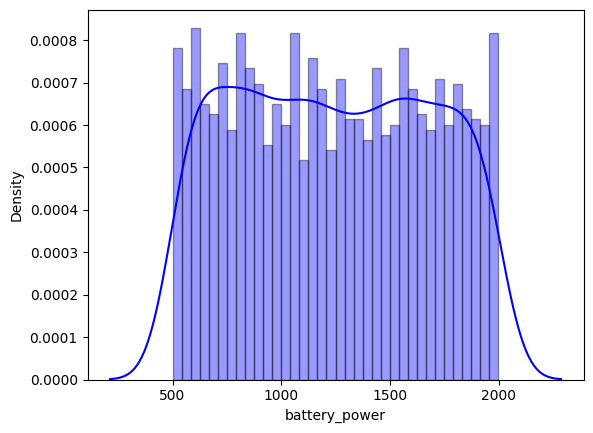

In [ ]:
# Гистограмма
sns.distplot(df['battery_power'], hist=True, kde=True,
             bins=int(180/5), color = 'blue',
             hist_kws={'edgecolor':'black'})

<Axes: xlabel='battery_power'>

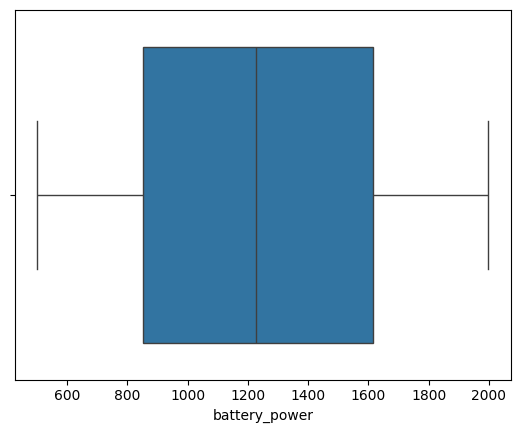

In [ ]:
# box-plot
sns.boxplot(data=df, x="battery_power")

In [ ]:
wifi_sup = df[df["wifi"]==1]
print(wifi_sup)
df = wifi_sup

      battery_power  blue  clock_speed  dual_sim  fc  four_g  int_memory  \
0               842     0          2.2         0   1       0           7   
6              1821     0          1.7         0   4       1          10   
7              1954     0          0.5         1   0       0          24   
11             1520     1          2.2         0   5       1          33   
13              803     1          2.1         0   7       0          17   
...             ...   ...          ...       ...  ..     ...         ...   
1992            674     1          2.9         1   1       0          21   
1993           1467     1          0.5         0   0       0          18   
1996           1965     1          2.6         1   0       0          39   
1998           1512     0          0.9         0   4       1          46   
1999            510     1          2.0         1   5       1          45   

      m_dep  mobile_wt  n_cores  ...  px_height  px_width   ram  sc_h  sc_w  \
0       

In [ ]:
# Вывод результатов для поддерживающих Wi-Fi
print(df_sum('dual_sim'))
print(df_sum('three_g'))
print(df_max('n_cores'))
print(df_mean('battery_power'))
#print(df_variance('battery_power'))
print(df_median('battery_power'))
print(df_quantile('battery_power', 0.4))

528
774
8
1234
802.5
1077.8000000000002


<Axes: xlabel='battery_power', ylabel='Density'>

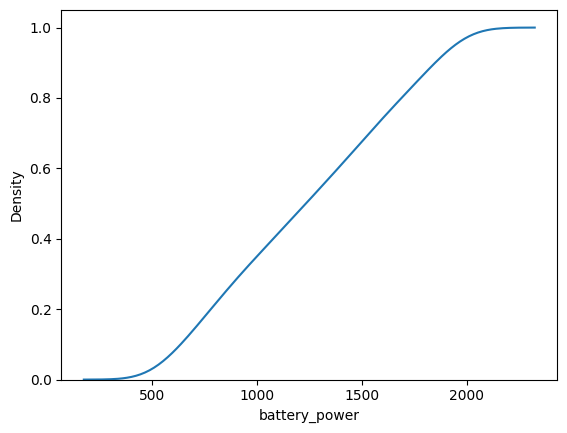

In [ ]:
sns.kdeplot(df['battery_power'], cumulative=True)

<ipython-input-179-d314d7824bc5>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['battery_power'], hist=True, kde=True,


<Axes: xlabel='battery_power', ylabel='Density'>

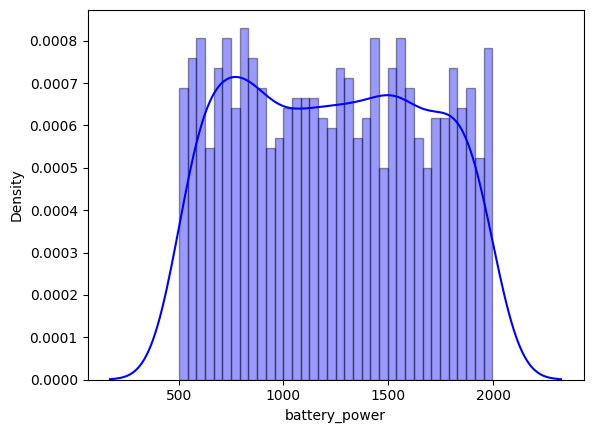

In [ ]:
sns.distplot(df['battery_power'], hist=True, kde=True,
             bins=int(180/5), color = 'blue',
             hist_kws={'edgecolor':'black'})

<Axes: xlabel='battery_power'>

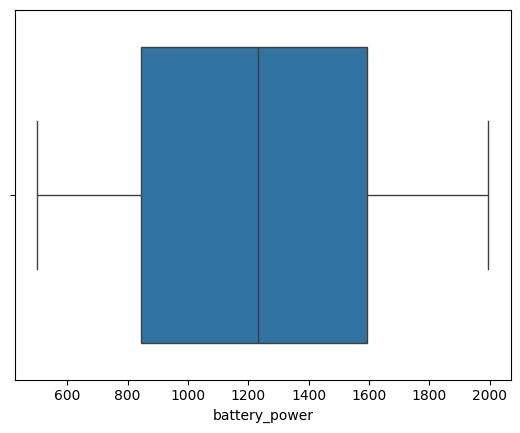

In [ ]:
sns.boxplot(data=df, x="battery_power")

In [ ]:
df = pd.read_csv('/mobile_phones.csv')
wifi_unsup = df[df["wifi"]==0]
print(wifi_unsup)
df = wifi_unsup

      battery_power  blue  clock_speed  dual_sim  fc  four_g  int_memory  \
1              1021     1          0.5         1   0       1          53   
2               563     1          0.5         1   2       1          41   
3               615     1          2.5         0   0       0          10   
4              1821     1          1.2         0  13       1          44   
5              1859     0          0.5         1   3       0          22   
...             ...   ...          ...       ...  ..     ...         ...   
1990           1617     1          2.4         0   8       1          36   
1991           1882     0          2.0         0  11       1          44   
1994            858     0          2.2         0   1       0          50   
1995            794     1          0.5         1   0       1           2   
1997           1911     0          0.9         1   1       1          36   

      m_dep  mobile_wt  n_cores  ...  px_height  px_width   ram  sc_h  sc_w  \
1       

In [ ]:
# Вывод результатов для не поддерживающих Wi-Fi
print(df_sum('dual_sim'))
print(df_sum('three_g'))
print(df_max('n_cores'))
print(df_mean('battery_power'))
#print(df_variance('battery_power'))
print(df_median('battery_power'))
print(df_quantile('battery_power', 0.4))

491
749
8
1242
2514.5
1076.0


<Axes: xlabel='battery_power', ylabel='Density'>

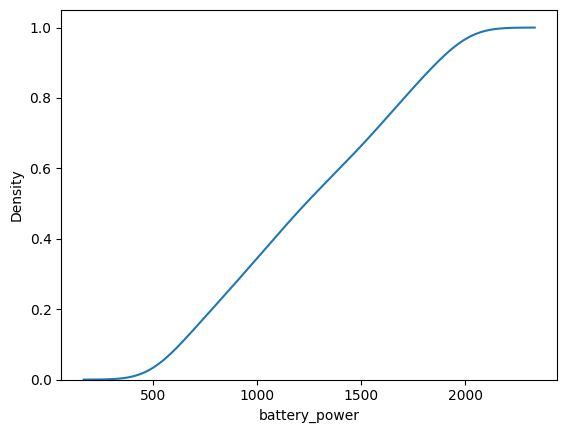

In [ ]:
sns.kdeplot(df['battery_power'], cumulative=True)

<ipython-input-184-d314d7824bc5>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['battery_power'], hist=True, kde=True,


<Axes: xlabel='battery_power', ylabel='Density'>

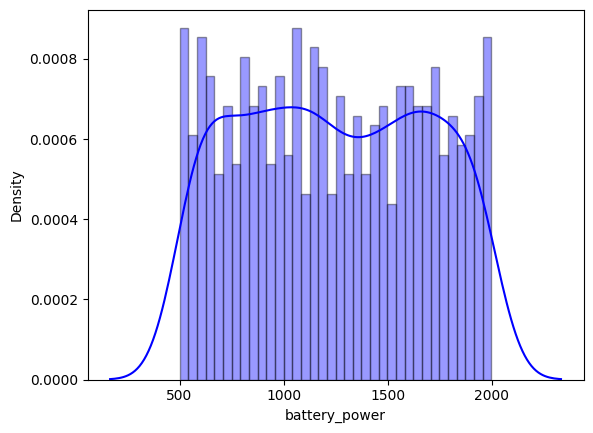

In [ ]:
sns.distplot(df['battery_power'], hist=True, kde=True,
             bins=int(180/5), color = 'blue',
             hist_kws={'edgecolor':'black'})

<Axes: xlabel='battery_power'>

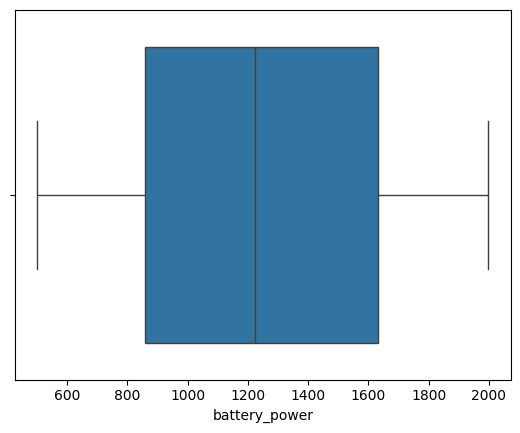

In [ ]:
sns.boxplot(data=df, x="battery_power")